In [5]:
# ==========================================
# ANALYSIS #1: THE VETERAN "WALL"
# CELL 1: WRAPPER INITIALIZATION & METADATA
# ==========================================

from nhlpy import NHLClient # The 2026-standard wrapper
import pandas as pd
from datetime import datetime
import time

# Initialize the client - the wrapper handles headers and timeouts internally
client = NHLClient()

TEAM_ABBR = "DET"
SEASON = "20252026"
MID_SEASON_BREAK = datetime.strptime("2026-02-06", "%Y-%m-%d")

# Grouping our core players by experience
COHORT_GROUPS = {
    "Larkin": "Vet", "DeBrincat": "Vet", "Compher": "Vet", "Copp": "Vet",
    "Raymond": "Young", "Seider": "Young", "Edvinsson": "Young", "Kasper": "Young"
}

print(f"[Config] NHLClient initialized. Ready to pull {SEASON} data.")

[Config] NHLClient initialized. Ready to pull 20252026 data.


In [13]:
# ==========================================
# ANALYSIS #1: THE VETERAN "WALL"
# CELL 2: THE "PHANTOM NAME" FIX
# ==========================================

import time
import pandas as pd
from datetime import datetime

# Step 1: Fetch the schedule
schedule_response = client.schedule.team_season_schedule(team_abbr=TEAM_ABBR, season=SEASON)
games_list = schedule_response.get('games', [])

age_telemetry = []
print(f"[Process] Analyzing {len(games_list)} games...")

for index, game in enumerate(games_list):
    game_id = str(game.get('id'))
    
    # Filter for Regular Season ('02')
    if game_id[4:6] != '02': 
        continue
    
    # Calculate Season Phase
    game_date_str = game.get('gameDate')
    game_date = datetime.strptime(game_date_str, "%Y-%m-%d")
    season_phase = "Early" if game_date < MID_SEASON_BREAK else "Late"
    
    try:
        # Rate-limiting for API stability
        time.sleep(0.7) 
        data = client.game_center.boxscore(game_id=game_id)
        
        player_data_root = data.get('playerByGameStats', {})
        
        # Determine if Detroit was Home or Away
        is_away = data.get('awayTeam', {}).get('abbrev') == TEAM_ABBR
        side_key = 'awayTeam' if is_away else 'homeTeam'
        
        detroit_players = player_data_root.get(side_key, {})
        skaters = detroit_players.get('forwards', []) + detroit_players.get('defense', [])

        for p in skaters:
            # --- THE FIX ---
            # The API no longer uses 'lastName'. We extract the full name and split it.
            # E.g., {"name": {"default": "Dylan Larkin"}} -> "Dylan Larkin" -> "Larkin"
            full_name = p.get('name', {}).get('default', '')
            
            # Grab the last word in the name string
            last_name = full_name.split(' ')[-1] if full_name else ''
            
            if last_name in COHORT_GROUPS:
                # TOI is provided as a string "MM:SS"
                toi_str = p.get('toi', '00:00')
                m, s = map(int, toi_str.split(':'))
                toi_dec = m + (s / 60.0)
                
                if toi_dec > 0:
                    goals = p.get('goals', 0)
                    sog = p.get('sog', 0)
                    
                    age_telemetry.append({
                        'player': last_name,
                        'age_group': COHORT_GROUPS[last_name],
                        'season_phase': season_phase,
                        'sog_per_60': (sog / toi_dec) * 60,
                        'shooting_pct': (goals / sog * 100) if sog > 0 else 0.0
                    })
                    
    except Exception as e:
        continue

# Step 3: DataFrame and Aggregate
df_age = pd.DataFrame(age_telemetry)

if not df_age.empty:
    print(f"\n[Success] Captured {len(df_age)} player-game records.")
    summary = df_age.groupby(['season_phase', 'age_group'])[['sog_per_60', 'shooting_pct']].mean()
    display(summary)
else:
    print("\n[Error] Still no data.")

[Process] Analyzing 90 games...

[Success] Captured 632 player-game records.


sog_per_60  shooting_pct
season_phase age_group                          
Early        Vet          7.679071     11.173030
             Young        5.636224      7.021092
Late         Vet          7.386458      8.726891
             Young        5.913082      6.718750

[Success] Visualization saved as 'veteran_wall_analysis.png'


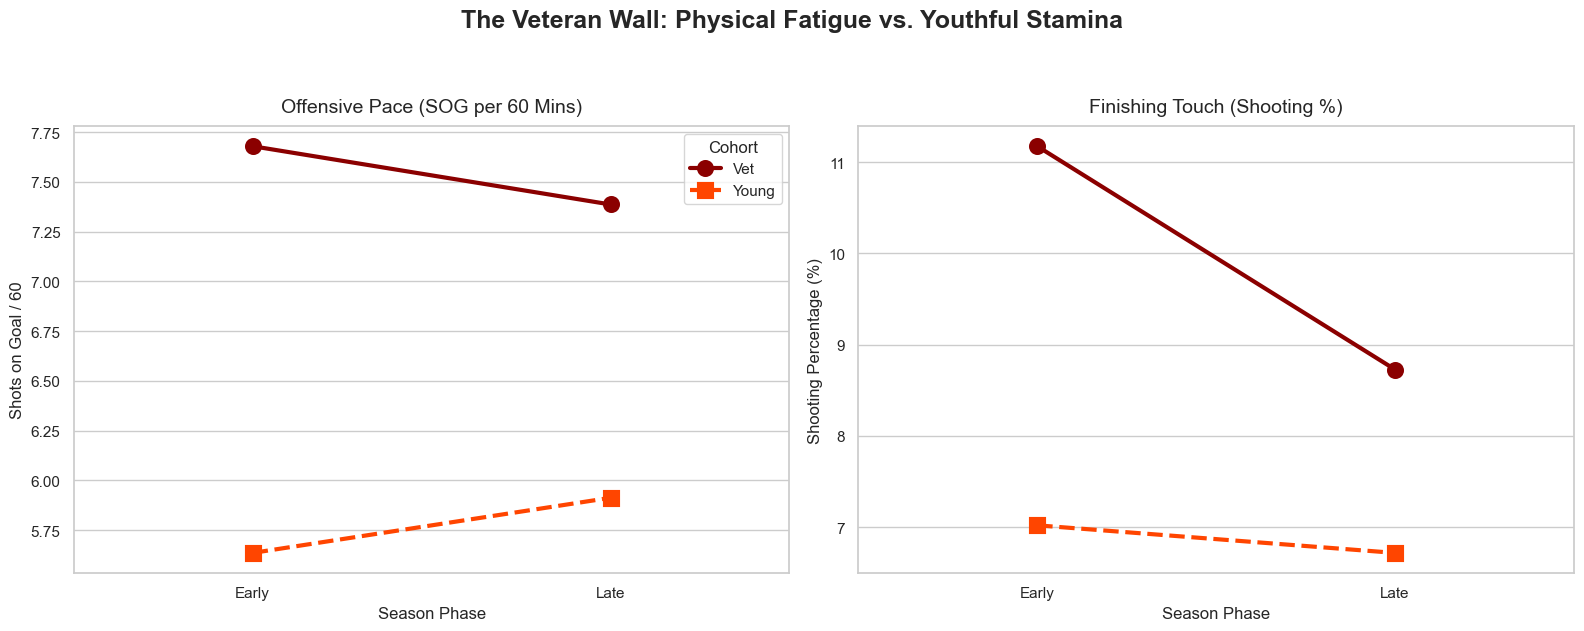

In [14]:
# ==========================================
# ANALYSIS #1: THE VETERAN "WALL"
# CELL 3: PORTFOLIO VISUALIZATION
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the style for a professional look
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('The Veteran Wall: Physical Fatigue vs. Youthful Stamina', fontsize=18, fontweight='bold', y=1.05)

# We need to flatten the multi-index dataframe for Seaborn
df_viz = summary.reset_index()

# Custom colors: Dark Red for Vets, Bright Red/Orange for Youth
palette = {"Vet": "#8B0000", "Young": "#FF4500"}

# --- CHART 1: Shot Volume (SOG/60) ---
sns.pointplot(
    data=df_viz, x='season_phase', y='sog_per_60', hue='age_group',
    palette=palette, markers=['o', 's'], linestyles=['-', '--'],
    linewidth=3, markersize=10, ax=axes[0]
)
axes[0].set_title('Offensive Pace (SOG per 60 Mins)', fontsize=14, pad=10)
axes[0].set_xlabel('Season Phase', fontsize=12)
axes[0].set_ylabel('Shots on Goal / 60', fontsize=12)

# --- CHART 2: Finishing Efficiency (Shooting %) ---
sns.pointplot(
    data=df_viz, x='season_phase', y='shooting_pct', hue='age_group',
    palette=palette, markers=['o', 's'], linestyles=['-', '--'],
    linewidth=3, markersize=10, ax=axes[1]
)
axes[1].set_title('Finishing Touch (Shooting %)', fontsize=14, pad=10)
axes[1].set_xlabel('Season Phase', fontsize=12)
axes[1].set_ylabel('Shooting Percentage (%)', fontsize=12)

# Clean up legends
axes[0].legend(title='Cohort')
axes[1].get_legend().remove()

plt.tight_layout()
plt.savefig('veteran_wall_analysis.png', bbox_inches='tight', dpi=300)
print("[Success] Visualization saved as 'veteran_wall_analysis.png'")
plt.show()